In [94]:
import pandas as pd

df = pd.read_csv("/content/eda_feature_scaling_column_transformer_dataset.csv")

df.head()

,Employee_ID,Age,Gender,City,Education_Level,Employment_Type,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Satisfaction_Level,Has_Certification,Performance_Score,Promoted
0,1,58.0,Female,Rawalpindi,Master,Full-time,4.2,83466.0,52.0,Low,Yes,68.5,No
1,2,19.0,Female,Islamabad,Intermediate,Part-time,0.6,11502.0,28.0,Medium,No,39.5,No
2,3,18.0,Female,Karachi,Intermediate,Full-time,0.0,23259.0,38.0,Medium,Yes,60.0,No
3,4,34.0,Female,Karachi,Bachelor,NaN,6.1,0.0,5.0,Medium,No,56.9,No
4,5,20.0,NaN,NaN,PhD,Freelance,1.7,53235.0,33.0,Low,Yes,67.9,No


In [95]:
df.sample(5
          )

,Employee_ID,Age,Gender,City,Education_Level,Employment_Type,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Satisfaction_Level,Has_Certification,Performance_Score,Promoted
56,57,39.0,Female,Karachi,Master,Full-time,4.5,71990.0,54.0,High,Yes,69.0,No
217,218,20.0,Male,Peshawar,Bachelor,Unemployed,0.2,4841.0,2.0,Medium,Yes,73.0,No
261,262,45.0,Female,Islamabad,Intermediate,Freelance,NaN,78748.0,30.0,Medium,Yes,93.9,No
48,49,31.0,Male,Lahore,Intermediate,Freelance,3.6,44780.0,15.0,Medium,No,52.4,No
269,270,48.0,Female,Rawalpindi,Intermediate,Full-time,6.0,57974.0,55.0,High,Yes,63.1,No


In [96]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          300 non-null    int64  
 1   Age                  290 non-null    float64
 2   Gender               293 non-null    object 
 3   City                 292 non-null    object 
 4   Education_Level      293 non-null    object 
 5   Employment_Type      294 non-null    object 
 6   Experience_Years     290 non-null    float64
 7   Monthly_Income_PKR   288 non-null    float64
 8   Work_Hours_Per_Week  291 non-null    float64
 9   Satisfaction_Level   293 non-null    object 
 10  Has_Certification    294 non-null    object 
 11  Performance_Score    290 non-null    float64
 12  Promoted             300 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 30.6+ KB


In [97]:
df.shape


(300, 13)

In [98]:
df.describe()

,Employee_ID,Age,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Performance_Score
count,300.000000,290.000000,290.000000,288.000000,291.000000,290.000000
mean,150.500000,38.362069,9.484138,61858.951389,36.329897,67.755862
std,86.746758,12.977354,7.947402,45809.828694,15.600213,14.358998
min,1.000000,18.000000,0.000000,0.000000,0.000000,25.000000
25%,75.750000,26.000000,3.100000,34495.750000,24.000000,59.225000
50%,150.500000,38.000000,7.350000,54254.500000,40.000000,68.100000
75%,225.250000,50.000000,14.575000,81960.500000,48.000000,77.050000
max,300.000000,60.000000,30.000000,350000.000000,80.000000,100.000000


In [99]:
df.describe(include='object')

,Gender,City,Education_Level,Employment_Type,Satisfaction_Level,Has_Certification,Promoted
count,293,292,293,294,293,294,300
unique,2,5,5,4,3,2,2
top,Male,Lahore,Bachelor,Full-time,Medium,Yes,No
freq,148,65,94,160,145,165,240


In [100]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,7
City,8
Education_Level,7
Employment_Type,6
Experience_Years,10
Monthly_Income_PKR,12
Work_Hours_Per_Week,9
Satisfaction_Level,7


In [101]:
(df.isnull().sum() / len(df)) * 100


,0
Employee_ID,0.000000
Age,3.333333
Gender,2.333333
City,2.666667
Education_Level,2.333333
Employment_Type,2.000000
Experience_Years,3.333333
Monthly_Income_PKR,4.000000
Work_Hours_Per_Week,3.000000
Satisfaction_Level,2.333333


## ## 1. Dataset Overview

- Dataset contains 300 rows and 13 columns.
- Dataset contains both numerical and categorical features.
- Missing values are present in several columns.
- `Promoted` is the target variable.
- `Employee_ID` is an identifier and will not be used for model training.

In [102]:
!pip install ydata-profiling


In [103]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Employee Promotion EDA Report",
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 39.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [104]:
profile.to_file("employee_promotion_profile_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 3. Automated EDA using YData Profiling

YData Profiling report was generated to inspect:

- Missing values
- Data types
- Feature distributions
- Correlations
- Duplicate rows
- Skewness
- Potential outliers
- Categorical frequencies

## YData Profiling Findings

The automated profiling report highlighted:

- High correlation between Age and Experience_Years
- Strong relationship between Employment_Type and Work_Hours_Per_Week
- Monthly_Income_PKR is correlated with several numerical features
- Performance_Score is correlated with Experience_Years and related variables
- Promoted shows notable association with Monthly_Income_PKR and other features
- Missing values are present across several columns, mostly between 2% and 4%
- Employee_ID contains unique values and will not be used for model training
- Zero values in Experience_Years and Monthly_Income_PKR may be valid observations

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.nunique()

,0
Employee_ID,300
Age,43
Gender,2
City,5
Education_Level,5
Employment_Type,4
Experience_Years,160
Monthly_Income_PKR,283
Work_Hours_Per_Week,55
Satisfaction_Level,3


In [107]:
df.corr(numeric_only=True)

,Employee_ID,Age,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Performance_Score
Employee_ID,1.000000,0.020332,-0.002425,0.043509,0.081408,0.007915
Age,0.020332,1.000000,0.637935,0.376491,0.056897,0.337011
Experience_Years,-0.002425,0.637935,1.000000,0.568690,0.031209,0.623557
Monthly_Income_PKR,0.043509,0.376491,0.568690,1.000000,0.262895,0.481080
Work_Hours_Per_Week,0.081408,0.056897,0.031209,0.262895,1.000000,0.107036
Performance_Score,0.007915,0.337011,0.623557,0.481080,0.107036,1.000000


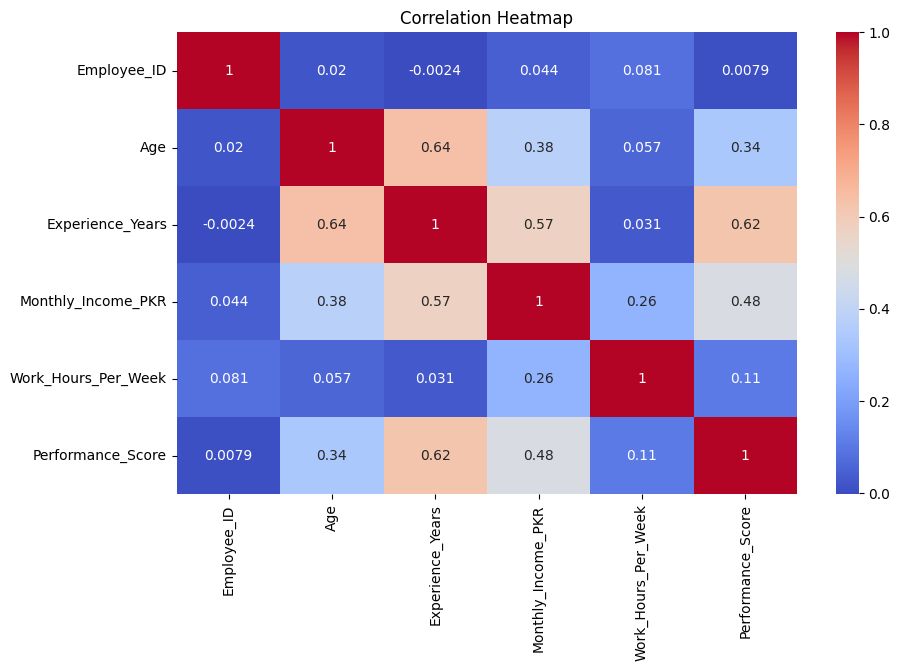

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

- Age and Experience_Years show a moderate-to-strong positive correlation (~0.64).
- Experience_Years is positively correlated with Performance_Score (~0.62).
- Experience_Years is also positively correlated with Monthly_Income_PKR (~0.57).
- Monthly_Income_PKR and Performance_Score show a moderate positive relationship (~0.48).
- Work_Hours_Per_Week has relatively weak linear relationships with most numerical features.
- Employee_ID shows no meaningful relationship with the predictive features and will be removed before modeling.

In [109]:
df['Promoted'].value_counts()

,count
Promoted,
No,240
Yes,60


In [110]:
df['Promoted'].value_counts(normalize=True) * 100

,proportion
Promoted,
No,80.0
Yes,20.0


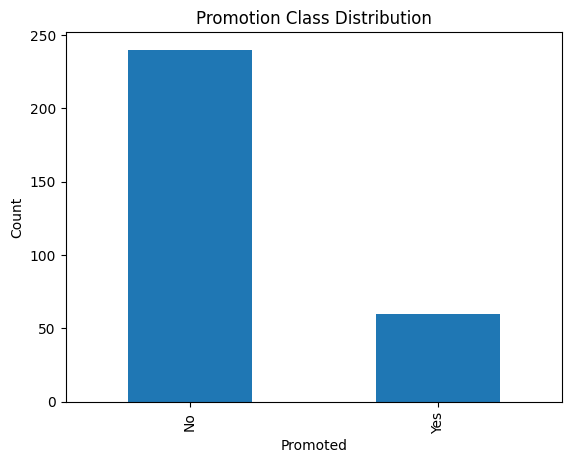

In [111]:
import matplotlib.pyplot as plt

df['Promoted'].value_counts().plot(kind='bar')
plt.title('Promotion Class Distribution')
plt.xlabel('Promoted')
plt.ylabel('Count')
plt.show()

## Target Variable Analysis

The target variable `Promoted` is imbalanced.

- No: 240 observations (80%)
- Yes: 60 observations (20%)

Because the target is imbalanced, model evaluation will not rely on accuracy alone.
Precision, recall, F1-score, and confusion matrix will also be considered.
A stratified train-test split will be used to preserve the class distribution.

In [112]:
categorical_cols = [
    'Gender',
    'City',
    'Education_Level',
    'Employment_Type',
    'Satisfaction_Level',
    'Has_Certification'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Gender ---
Gender
Male      148
Female    145
NaN         7
Name: count, dtype: int64

--- City ---
City
Lahore        65
Peshawar      60
Islamabad     58
Rawalpindi    58
Karachi       51
NaN            8
Name: count, dtype: int64

--- Education_Level ---
Education_Level
Bachelor        94
Master          80
Intermediate    68
Matric          35
PhD             16
NaN              7
Name: count, dtype: int64

--- Employment_Type ---
Employment_Type
Full-time     160
Freelance      68
Part-time      44
Unemployed     22
NaN             6
Name: count, dtype: int64

--- Satisfaction_Level ---
Satisfaction_Level
Medium    145
High       86
Low        62
NaN         7
Name: count, dtype: int64

--- Has_Certification ---
Has_Certification
Yes    165
No     129
NaN      6
Name: count, dtype: int64


In [113]:
pd.crosstab(df['Education_Level'], df['Promoted'], normalize='index') * 100

Promoted,No,Yes
Education_Level,,
Bachelor,81.914894,18.085106
Intermediate,91.176471,8.823529
Master,63.750000,36.250000
Matric,94.285714,5.714286
PhD,75.000000,25.000000


In [114]:
pd.crosstab(df['Employment_Type'], df['Promoted'], normalize='index') * 100

Promoted,No,Yes
Employment_Type,,
Freelance,75.000,25.000
Full-time,74.375,25.625
Part-time,100.000,0.000
Unemployed,100.000,0.000


## Categorical Feature Analysis

- Gender distribution is nearly balanced.
- City distribution is reasonably even across the five cities.
- Bachelor and Master are the most common education levels.
- Full-time employment is the dominant employment type.
- Medium is the most common satisfaction level.
- Certification status is slightly skewed toward "Yes".

### Relationship with Promotion

- Promotion rates are higher for Master and PhD education levels.
- Full-time and Freelance employees show promotion rates around 25%.
- No promotions are observed among Part-time and Unemployed employees in this dataset.
- These patterns indicate association, not causation.

In [115]:
numeric_cols = [
    'Age',
    'Experience_Years',
    'Monthly_Income_PKR',
    'Work_Hours_Per_Week',
    'Performance_Score'
]

df[numeric_cols].median()

,0
Age,38.00
Experience_Years,7.35
Monthly_Income_PKR,54254.50
Work_Hours_Per_Week,40.00
Performance_Score,68.10


In [116]:
categorical_cols = [
    'Gender',
    'City',
    'Education_Level',
    'Employment_Type',
    'Satisfaction_Level',
    'Has_Certification'
]

for col in categorical_cols:
    print(col, "->", df[col].mode()[0])

Gender -> Male
City -> Lahore
Education_Level -> Bachelor
Employment_Type -> Full-time
Satisfaction_Level -> Medium
Has_Certification -> Yes


### Why Median Imputation?

Median imputation was selected for numerical features because it is less sensitive to outliers and skewed distributions than the mean. This is especially important for Monthly_Income_PKR, which contains high-value outliers.

In [117]:
numeric_cols = [
    'Age',
    'Experience_Years',
    'Monthly_Income_PKR',
    'Work_Hours_Per_Week',
    'Performance_Score'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())



In [118]:
categorical_cols = [
    'Gender',
    'City',
    'Education_Level',
    'Employment_Type',
    'Satisfaction_Level',
    'Has_Certification'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [119]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
City,0
Education_Level,0
Employment_Type,0
Experience_Years,0
Monthly_Income_PKR,0
Work_Hours_Per_Week,0
Satisfaction_Level,0


## Missing Value Treatment

Numerical missing values were filled using median imputation because median is more robust to outliers and skewed distributions.

Categorical missing values were filled using the most frequent category (mode).

After imputation, the dataset was checked again to confirm that no missing values remained.

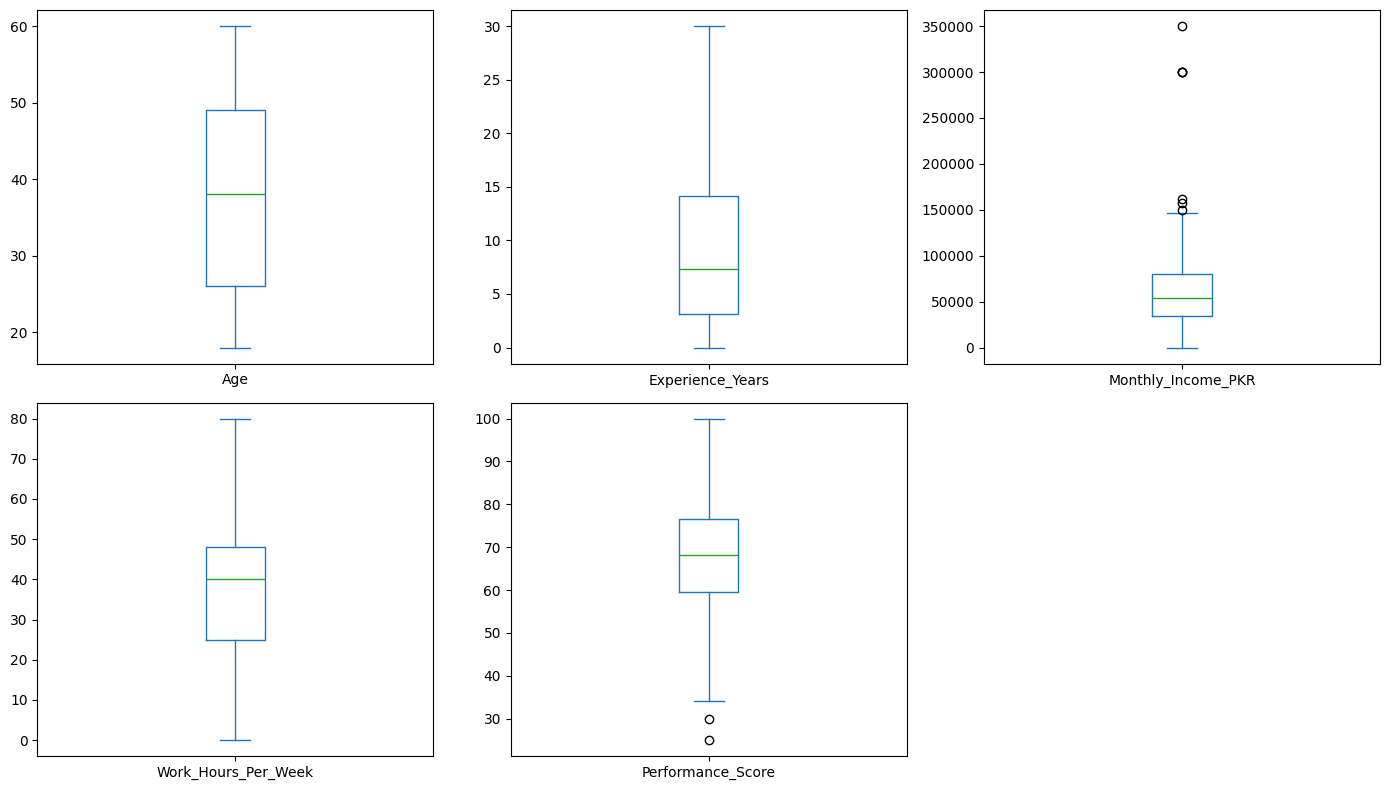

In [120]:
import matplotlib.pyplot as plt

numeric_cols = [
    'Age',
    'Experience_Years',
    'Monthly_Income_PKR',
    'Work_Hours_Per_Week',
    'Performance_Score'
]

df[numeric_cols].plot(
    kind='box',
    subplots=True,
    layout=(2,3),
    figsize=(14,8),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

In [121]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print()

Age: 0 outliers
Lower bound: -8.50, Upper bound: 83.50

Experience_Years: 0 outliers
Lower bound: -13.44, Upper bound: 30.66

Monthly_Income_PKR: 7 outliers
Lower bound: -33746.62, Upper bound: 148766.38

Work_Hours_Per_Week: 0 outliers
Lower bound: -9.50, Upper bound: 82.50

Performance_Score: 2 outliers
Lower bound: 33.84, Upper bound: 102.14



## Outlier Analysis

Boxplots were used to inspect numerical features.

- Age and Experience_Years did not show major outlier concerns.
- Monthly_Income_PKR contains several high-value outliers.
- Performance_Score contains a small number of low-end outliers.
- Outliers were retained because they may represent valid observations rather than data errors.

In [122]:
df = df.drop(columns=['Employee_ID'])

In [123]:
df.head()

,Age,Gender,City,Education_Level,Employment_Type,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Satisfaction_Level,Has_Certification,Performance_Score,Promoted
0,58.0,Female,Rawalpindi,Master,Full-time,4.2,83466.0,52.0,Low,Yes,68.5,No
1,19.0,Female,Islamabad,Intermediate,Part-time,0.6,11502.0,28.0,Medium,No,39.5,No
2,18.0,Female,Karachi,Intermediate,Full-time,0.0,23259.0,38.0,Medium,Yes,60.0,No
3,34.0,Female,Karachi,Bachelor,Full-time,6.1,0.0,5.0,Medium,No,56.9,No
4,20.0,Male,Lahore,PhD,Freelance,1.7,53235.0,33.0,Low,Yes,67.9,No


In [124]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Promoted'])
print(y)

[0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 1 1 1 0]


In [125]:
X = df.drop(columns=['Promoted'])
print(X)
X.shape

      Age  Gender        City Education_Level Employment_Type  \
0    58.0  Female  Rawalpindi          Master       Full-time   
1    19.0  Female   Islamabad    Intermediate       Part-time   
2    18.0  Female     Karachi    Intermediate       Full-time   
3    34.0  Female     Karachi        Bachelor       Full-time   
4    20.0    Male      Lahore             PhD       Freelance   
..    ...     ...         ...             ...             ...   
295  48.0    Male      Lahore          Matric       Freelance   
296  32.0  Female      Lahore             PhD       Full-time   
297  44.0    Male    Peshawar          Master       Freelance   
298  54.0  Female   Islamabad    Intermediate       Freelance   
299  50.0    Male  Rawalpindi        Bachelor       Full-time   

     Experience_Years  Monthly_Income_PKR  Work_Hours_Per_Week  \
0                 4.2             83466.0                 52.0   
1                 0.6             11502.0                 28.0   
2                 0.0

(300, 11)

### Target Encoding

The target variable `Promoted` was encoded using `LabelEncoder`:

- No = 0
- Yes = 1

In [126]:
from sklearn.model_selection import train_test_split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [127]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 11)
(60, 11)
(240,)
(60,)


In [128]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = [
    'Education_Level',
    'Satisfaction_Level'
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ['Matric', 'Intermediate', 'Bachelor', 'Master', 'PhD'],
        ['Low', 'Medium', 'High']
    ]
)

train_ordinal = ordinal_encoder.fit_transform(X_train[ordinal_cols])
test_ordinal = ordinal_encoder.transform(X_test[ordinal_cols])

In [130]:
import pandas as pd

train_ordinal_df = pd.DataFrame(
    train_ordinal,
    columns=ordinal_cols,
    index=X_train.index
)

test_ordinal_df = pd.DataFrame(
    test_ordinal,
    columns=ordinal_cols,
    index=X_test.index
)

In [131]:
train_ordinal_df.head()

,Education_Level,Satisfaction_Level
3,2.0,1.0
202,1.0,1.0
174,3.0,1.0
247,2.0,0.0
23,2.0,1.0


In [132]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = [
    'Gender',
    'City',
    'Employment_Type'
]

ohe = OneHotEncoder(
     drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

train_nominal = ohe.fit_transform(X_train[nominal_cols])
test_nominal = ohe.transform(X_test[nominal_cols])

In [133]:
print(type(train_nominal))
print(train_nominal.shape)

<class 'numpy.ndarray'>
(240, 8)


In [134]:
ohe_columns = ohe.get_feature_names_out(nominal_cols)

ohe_columns

array(['Gender_Male', 'City_Karachi', 'City_Lahore', 'City_Peshawar',
       'City_Rawalpindi', 'Employment_Type_Full-time',
       'Employment_Type_Part-time', 'Employment_Type_Unemployed'],
      dtype=object)

In [135]:
train_nominal_df = pd.DataFrame(
    train_nominal,
    columns=ohe_columns,
    index=X_train.index
)

test_nominal_df = pd.DataFrame(
    test_nominal,
    columns=ohe_columns,
    index=X_test.index
)

In [136]:
train_nominal_df.head()

,Gender_Male,City_Karachi,City_Lahore,City_Peshawar,City_Rawalpindi,Employment_Type_Full-time,Employment_Type_Part-time,Employment_Type_Unemployed
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
174,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
247,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
23,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [138]:
# Binary encoding
X_train['Has_Certification'] = X_train['Has_Certification'].map({
    'No': 0,
    'Yes': 1
})

X_test['Has_Certification'] = X_test['Has_Certification'].map({
    'No': 0,
    'Yes': 1
})

In [139]:
X_train['Has_Certification'].value_counts()

,count
Has_Certification,
1,141
0,99


In [140]:
numeric_cols = [
    'Age',
    'Experience_Years',
    'Monthly_Income_PKR',
    'Work_Hours_Per_Week',
    'Performance_Score'
]

In [141]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_numeric = scaler.fit_transform(X_train[numeric_cols])
test_numeric = scaler.transform(X_test[numeric_cols])


In [142]:
train_numeric_df = pd.DataFrame(
    train_numeric,
    columns=numeric_cols,
    index=X_train.index
)

test_numeric_df = pd.DataFrame(
    test_numeric,
    columns=numeric_cols,
    index=X_test.index
)

In [143]:
train_numeric_df.head()

,Age,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Performance_Score
3,-0.348633,-0.423990,-1.447798,-2.042022,-0.779915
202,-1.143994,-0.527030,-0.623119,-1.451558,-0.333338
174,-0.984922,-0.810388,-0.123779,0.582263,-0.241187
247,1.242089,0.606402,0.770481,1.107120,-0.042708
23,-0.030489,-0.527030,0.199149,0.844692,0.099062


In [144]:
train_binary_df = X_train[['Has_Certification']].copy()
test_binary_df = X_test[['Has_Certification']].copy()

X_train_processed = pd.concat(
    [
        train_numeric_df,
        train_ordinal_df,
        train_nominal_df,
        train_binary_df
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        test_numeric_df,
        test_ordinal_df,
        test_nominal_df,
        test_binary_df
    ],
    axis=1
)

In [145]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(240, 16)
(60, 16)


In [146]:
X_train_processed.head()


,Age,Experience_Years,Monthly_Income_PKR,Work_Hours_Per_Week,Performance_Score,Education_Level,Satisfaction_Level,Gender_Male,City_Karachi,City_Lahore,City_Peshawar,City_Rawalpindi,Employment_Type_Full-time,Employment_Type_Part-time,Employment_Type_Unemployed,Has_Certification
3,-0.348633,-0.423990,-1.447798,-2.042022,-0.779915,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
202,-1.143994,-0.527030,-0.623119,-1.451558,-0.333338,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
174,-0.984922,-0.810388,-0.123779,0.582263,-0.241187,3.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
247,1.242089,0.606402,0.770481,1.107120,-0.042708,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
23,-0.030489,-0.527030,0.199149,0.844692,0.099062,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [147]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X_train_processed.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_train_processed.values,
        i
    )
    for i in range(X_train_processed.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
3,Work_Hours_Per_Week,3.188948
1,Experience_Years,3.172520
4,Performance_Score,3.132617
12,Employment_Type_Full-time,2.310392
2,Monthly_Income_PKR,2.132482
14,Employment_Type_Unemployed,2.018664
9,City_Lahore,1.765294
13,Employment_Type_Part-time,1.737673
0,Age,1.724325
5,Education_Level,1.698514


## Multicollinearity Check using VIF

Variance Inflation Factor (VIF) was calculated on the processed training features.

All features had VIF values below 5, indicating that there is no serious multicollinearity problem in the dataset.

Therefore, no features were removed based on VIF.

## Final Manual Preprocessing

The separately transformed numerical, ordinal, nominal, and binary features were combined into final training and testing DataFrames.

All preprocessing steps were fitted using the training data only to avoid data leakage.

In [148]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [149]:
y_pred = model.predict(X_test_processed)

In [150]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91        48
           1       0.61      0.92      0.73        12

    accuracy                           0.87        60
   macro avg       0.79      0.89      0.82        60
weighted avg       0.90      0.87      0.88        60


Confusion Matrix:
[[41  7]
 [ 1 11]]


## Logistic Regression Model Evaluation

The Logistic Regression model achieved approximately 86.7% accuracy.

Because the target variable is imbalanced, additional metrics were considered:

- Recall for the promoted class was 0.92
- Precision for the promoted class was 0.61
- F1-score for the promoted class was 0.73

The confusion matrix showed:
- 41 True Negatives
- 7 False Positives
- 1 False Negative
- 11 True Positives

The model performs well at identifying promoted employees, with very few false negatives.

In [151]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_processed)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9479166666666666


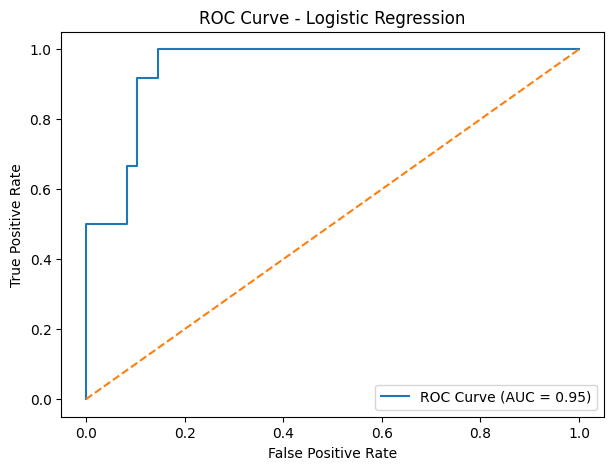

In [152]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## ROC-AUC Evaluation

The Logistic Regression model achieved a ROC-AUC score of approximately 0.95.

This indicates strong discrimination between promoted and non-promoted employees.

The model also achieved high recall for the promoted class, meaning that most promoted employees were correctly identified.

In [153]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [154]:
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

In [155]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        48
           1       0.83      0.83      0.83        12

    accuracy                           0.93        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.93      0.93      0.93        60


Confusion Matrix:
[[46  2]
 [ 2 10]]

ROC-AUC Score: 0.9618055555555555


## Random Forest Model

A Random Forest classifier was trained to compare its performance with Logistic Regression.

The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

## Model Comparison

Random Forest outperformed Logistic Regression on most evaluation metrics.

Random Forest achieved:
- Accuracy: 93.3%
- Precision for promoted class: 0.83
- Recall for promoted class: 0.83
- F1-score for promoted class: 0.83
- ROC-AUC: 0.962

Logistic Regression had slightly higher recall for the promoted class, but Random Forest provided better overall balance between precision and recall.

In [158]:
X = df.drop(columns=['Promoted', 'Employee_ID'], errors='ignore')
y = df['Promoted']

In [159]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [161]:
numeric_features = [
    'Age',
    'Experience_Years',
    'Monthly_Income_PKR',
    'Work_Hours_Per_Week',
    'Performance_Score'
]

nominal_features = [
    'Gender',
    'City',
    'Employment_Type',
    'Has_Certification'
]

ordinal_features = [
    'Education_Level',
    'Satisfaction_Level'
]

In [162]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [163]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [164]:
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='ignore'
    ))
])

In [165]:
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[
            ['Matric', 'Intermediate', 'Bachelor', 'Master', 'PhD'],
            ['Low', 'Medium', 'High']
        ],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [166]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('ordinal', ordinal_pipeline, ordinal_features)
])

In [167]:
from sklearn.ensemble import RandomForestClassifier

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

In [168]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Experience_Years',
                                                   'Monthly_Income_PKR',
                                                   'Work_Hours_Per_Week',
                                                   'Performance_Score']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEn...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Matric',
                                                                                               'Intermediate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'PhD'],
                                                                                              ['Low',
                                                                                               'Medium',
                                                                                               'High']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Education_Level',
                                                   'Satisfaction_Level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [169]:
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

In [170]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        48
           1       0.77      0.83      0.80        12

    accuracy                           0.92        60
   macro avg       0.86      0.89      0.87        60
weighted avg       0.92      0.92      0.92        60


Confusion Matrix:
[[45  3]
 [ 2 10]]

ROC-AUC: 0.9583333333333334


## Automated Preprocessing with ColumnTransformer

The manual preprocessing workflow was converted into a reusable ColumnTransformer and Pipeline.

- Numerical features: Median imputation + StandardScaler
- Nominal features: Most-frequent imputation + OneHotEncoder
- Ordinal features: Most-frequent imputation + OrdinalEncoder
- Model: Random Forest Classifier

This pipeline prevents data leakage and allows the same preprocessing steps to be applied consistently during training and prediction.

## Final Pipeline Evaluation

The final Random Forest pipeline using ColumnTransformer achieved:

- Accuracy: 91.7%
- Precision for promoted class: 0.77
- Recall for promoted class: 0.83
- F1-score for promoted class: 0.80
- ROC-AUC: 0.958

The pipeline combines preprocessing and model prediction in a single reusable workflow, making it suitable for deployment.

In [171]:
import joblib

joblib.dump(final_pipeline, "promotion_pipeline.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [177]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.4 MB/s eta 0:00:00


In [178]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load saved pipeline and label encoder
model = joblib.load("promotion_pipeline.pkl")
label_encoder = joblib.load("label_encoder.pkl")

st.title("Employee Promotion Prediction")

st.write("Enter employee details below:")

age = st.number_input("Age", min_value=18, max_value=70, value=30)

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

city = st.selectbox(
    "City",
    ["Rawalpindi", "Islamabad", "Lahore", "Karachi", "Peshawar"]
)

education = st.selectbox(
    "Education Level",
    ["Matric", "Intermediate", "Bachelor", "Master", "PhD"]
)

employment = st.selectbox(
    "Employment Type",
    ["Full-time", "Part-time", "Freelance", "Unemployed"]
)

experience = st.number_input(
    "Experience Years",
    min_value=0.0,
    max_value=40.0,
    value=5.0
)

income = st.number_input(
    "Monthly Income PKR",
    min_value=0.0,
    value=50000.0
)

work_hours = st.number_input(
    "Work Hours Per Week",
    min_value=0.0,
    max_value=100.0,
    value=40.0
)

satisfaction = st.selectbox(
    "Satisfaction Level",
    ["Low", "Medium", "High"]
)

certification = st.selectbox(
    "Has Certification",
    ["No", "Yes"]
)

performance = st.number_input(
    "Performance Score",
    min_value=0.0,
    max_value=100.0,
    value=70.0
)

if st.button("Predict Promotion"):

    input_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender],
        "City": [city],
        "Education_Level": [education],
        "Employment_Type": [employment],
        "Experience_Years": [experience],
        "Monthly_Income_PKR": [income],
        "Work_Hours_Per_Week": [work_hours],
        "Satisfaction_Level": [satisfaction],
        "Has_Certification": [certification],
        "Performance_Score": [performance]
    })

    prediction = model.predict(input_data)[0]

    prediction_label = label_encoder.inverse_transform([prediction])[0]

    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction Result")

    if prediction_label == "Yes":
        st.success("Employee is likely to be promoted.")
    else:
        st.warning("Employee is not likely to be promoted.")

    st.write(f"Promotion Probability: {probability:.2%}")

Overwriting app.py


In [179]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Overwriting requirements.txt


In [180]:
%pwd

'/content/Feature_scalling/Feature_scalling'

In [181]:
ls


app.py                                              label_encoder.pkl
eda_feature_scaling_column_transformer_dataset.csv  promotion_pipeline.pkl
employee_promotion_profile_report.html              requirements.txt


In [184]:
!streamlit run app.py --server.headless true



2026-09-17 15:27:54.863 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.41.59.173:8501

  Stopping...


In [186]:
%%writefile README.md

# Employee Promotion Prediction

This project demonstrates an end-to-end machine learning workflow for predicting employee promotions.

## Project Workflow

- Exploratory Data Analysis
- YData Profiling
- Missing Value Handling
- Outlier Detection
- Encoding
- Feature Scaling
- VIF Analysis
- Logistic Regression
- Random Forest
- ColumnTransformer
- Pipeline
- Streamlit Web App

## Final Pipeline Performance

- Accuracy: 91.7%
- ROC-AUC: 0.958
- Promoted Class Recall: 0.83
- Promoted Class F1-score: 0.80

Overwriting README.md
